# Example of LiDAR Georeferencing Using GTSAM

This notebook demonstrates how we can solve out georeferencing problem using GTSAM. Besides, high-level overview of mathematical concepts is included. 

**What is GTSAM?**
GTSAM (Georgia Tech Smoothing and Mapping) is a library that implements factor graph-based optimization. It's widely used in robotics for problems like SLAM, Structure from Motion (SfM), and sensor fusion.

**What is a Factor Graph?**
A factor graph is a graphical model that represents the probabilistic relationships between unknown variables (like robot poses and landmark positions) and measurements (like odometry or sensor readings). Optimization in GTSAM involves finding the most likely configuration of variables given the measurements and their associated uncertainties (noise).

**This Example:**
We'll simulate a drone flying in a 3D space. The drone has:
1.  **Odometry:** Measurements of its own motion (how far it moved between steps).
2.  **Bearing-Range LiDAR Sensor:** A sensor (like a simple laser scanner) that measures the bearing (3D unit vector) and range (distance) to landmarks.

We'll build a factor graph representing the drone's poses, landmark position, odometry measurements, and bearing-range measurements. Then, we'll use GTSAM to optimize the graph and find the best estimate of the robot's trajectory and landmark locations. This approach allows us to consider noise in the measurments. 

## 1. Setup and Imports

First, we need to import the necessary libraries: `gtsam` itself and `numpy` for numerical operations.

In [ ]:
%pip install --quiet gtsam-develop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.7/28.7 MB 44.6 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import graphviz

import gtsam
from gtsam import Point3, Pose3, Rot3
import plotly.graph_objects as go

# We can use shorthand symbols for variable keys
# X(i) represents the i-th pose variable
# L(j) represents the j-th landmark variable
from gtsam.symbol_shorthand import L, X

## 2. Setting up the drone

Suppose the drone is flying straight at an altitude of 200 meters, with a velocity of 10 meters per second. We’ll use an FLU (forward, left, up) body frame in an ENU (north, east, up) navigation frame. Here are three successive poses at intervals of 10 seconds:

In [ ]:
# Set up FLU body frame in ENU nav frame, flying North:
east = Point3(1, 0, 0)
north = Point3(0, 1, 0)
up = Point3(0, 0, 1)
nRb = Rot3(north, -east, up)  # body to nav

# Generate three Pose3 objects at 10-second intervals, flying straight at 200m altitude
nT1 = Pose3(nRb, Point3(0.0, 0.0, 200.0))
nT2 = Pose3(nRb, Point3(0.0, 100.0, 200.0))   # 10 m/s * 10 s = 100 m forward
nT3 = Pose3(nRb, Point3(0.0, 200.0, 200.0))   # 10 m/s * 20 s = 200 m forward
poses = [nT1, nT2, nT3]

print("Pose 1:", nT1)
print("Pose 2:", nT2)
print("Pose 3:", nT3)

Pose 1: R: [
	0, -1, 0;
	1, -0, 0;
	0, -0, 1
]
t:   0   0 200

Pose 2: R: [
	0, -1, 0;
	1, -0, 0;
	0, -0, 1
]
t:   0 100 200

Pose 3: R: [
	0, -1, 0;
	1, -0, 0;
	0, -0, 1
]
t:   0 200 200



Now, assume a landmark is located 200 m. to the east and 100 m. to the north of our starting point:

In [ ]:
landmark = Point3(200.0, 100.0, 0.0)  # landmark at (200, 100, 0)
print("Landmark:", landmark)

Landmark: [200. 100.   0.]


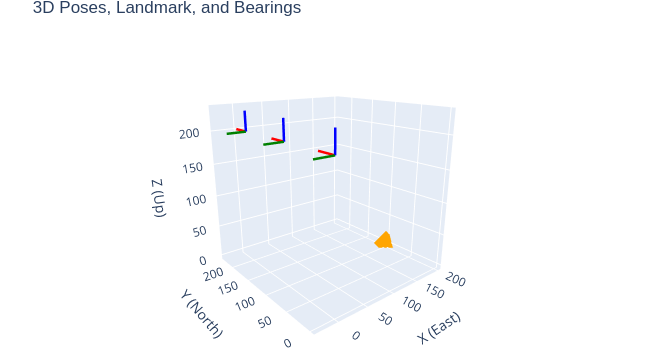

## 3. Creating Bearing-Range Measurments

Because we have the ground truth poses and landmark, we can compute the measurements we will get. In GTSAM, there is already a class for such measurements, BearingRange. The 3D variant has a static method that can compute bearing-range given a pose and a landmark.

### 3.2 Add a Prior Factor

To "anchor" the graph, we add a prior factor on the first pose $x_1$. This represents our initial belief about where the robot started. We assume it started at the origin (0, 0, 0) with the uncertainty defined by `PRIOR_NOISE`.

A `PriorFactorPose2` connects the single pose variable $x_1$ to a known pose (`gtsam.Pose2(0,0,0)`) with a specific noise model.

In [ ]:
measurements = [gtsam.BearingRange3D.Measure(pose, landmark) for pose in poses]
print("Measurements (bearing, range):\n")
for i, meas in enumerate(measurements):
    print(f"From Pose {i+1}:\nBearing (Unit3): {meas.bearing().point3()}, Range {meas.range()} (m)\n")

Measurements (bearing, range):

From Pose 1:
Bearing (Unit3): [ 0.33333333 -0.66666667 -0.66666667], Range 300.0 (m)

From Pose 2:
Bearing (Unit3): [ 0.         -0.70710678 -0.70710678], Range 282.842712474619 (m)

From Pose 3:
Bearing (Unit3): [-0.33333333 -0.66666667 -0.66666667], Range 300.0 (m)



Note that the bearing measurements are of type gtsam.Unit3, i.e., 3D unit vectors lying on a sphere of radius 1.0. This manifold is the right representations of directions in space.

Here is the situation plotted. Note that we have to convert bearing vectors into nav frame, and we’ll scale them with range:

In [ ]:
sight_vectors = [meas.range()*nRb.rotate(meas.bearing().point3()) for meas in measurements]
print("Sight Vectors (in nav frame):\n")
for i, vec in enumerate(sight_vectors):
    print(f"From Pose {i+1}: {vec}\n")

Sight Vectors (in nav frame):

From Pose 1: [ 200.  100. -200.]

From Pose 2: [ 200.    0. -200.]

From Pose 3: [ 200. -100. -200.]



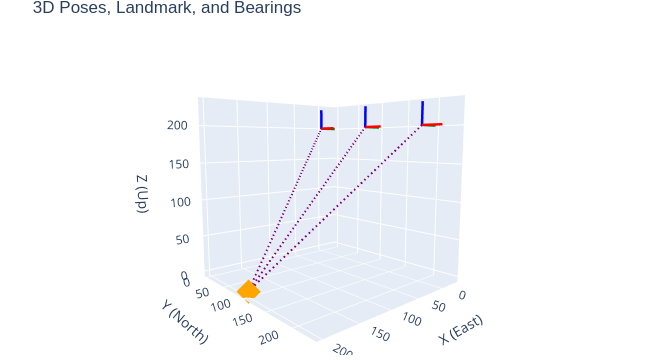

## 4. Sensor Info with GTSAM

Our drone will have at least one GPS module. For simplifications, we abstract the GPS module and assume that a navigation system that gives us Pose3 updates, with a covariance (noise). We create a factor graph with three prior factors to provide that information:

In [ ]:
# Create a NonlinearFactorGraph with three Pose3 prior factors at different locations.
graph3d = gtsam.NonlinearFactorGraph()

sigma_degree = 5
sigma_meter = 0.5
sigmas:np.ndarray = np.array([np.radians(sigma_degree)] * 3 + [sigma_meter] * 3)
PRIOR_NOISE = gtsam.noiseModel.Diagonal.Sigmas(sigmas)
for idx, nTk in enumerate(poses):
    # X(idx + 1) - symbolical key for a variable
    graph3d.addPriorPose3(X(idx+1), nTk, PRIOR_NOISE)

We then have three bearing range factors, created like this

In [ ]:
# Create a noise model (isotropic, 3D, sigma=0.5)
model3D = gtsam.noiseModel.Isotropic.Sigma(3, 0.5)

# Add noise to measurements
np.random.seed(42) # for reproducibility
noisy_measurements = []
for meas in measurements:
    # Add noise to bearing (as a small rotation)
    noisy_bearing = meas.bearing().retract(np.random.normal(0, 0.01, 3))
    # Add noise to range
    noisy_range = meas.range() + np.random.normal(0, 1.0) # Add 1 meter of noise
    noisy_measurements.append(gtsam.BearingRange3D(noisy_bearing, noisy_range))

# Create the 3D bearing-range factors
for idx, meas in enumerate(noisy_measurements):
    factor = gtsam.BearingRangeFactor3D(X(idx+1), L(1),
                                        meas.bearing(), meas.range(),
                                        model3D)
    graph3d.add(factor)

We wil set up an optimization problem starting from completely wrong values:

In [ ]:
# Set up values at the linearization point
initial_estimate = gtsam.Values()
for k, _ in enumerate(poses, 1):
  initial_estimate.insert(X(k), Pose3())
initial_estimate.insert(L(1), Point3(1,2,3))

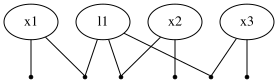

In [ ]:
display(graphviz.Source(graph3d.dot(initial_estimate)))

In [ ]:
initial_estimate

Values with 4 values:
Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	1;
	2;
	3
]

Value x1: (gtsam::Pose3)
R: [
	1, 0, 0;
	0, 1, 0;
	0, 0, 1
]
t: 0 0 0

Value x2: (gtsam::Pose3)
R: [
	1, 0, 0;
	0, 1, 0;
	0, 0, 1
]
t: 0 0 0

Value x3: (gtsam::Pose3)
R: [
	1, 0, 0;
	0, 1, 0;
	0, 0, 1
]
t: 0 0 0


## Optimization

Now, we use an optimizer to find the variable configuration that best fits all the factors (measurements) in the graph, starting from the initial estimate.

We’ll use the Levenberg-Marquardt (LM) algorithm, a standard non-linear least-squares optimizer.

  1. Create LM parameters (gtsam.LevenbergMarquardtParams). We’ll use the defaults.

  2. Create the optimizer instance, providing the graph, initial estimate, and parameters.

  3. Run the optimization by calling optimizer.optimize().

In [ ]:
# Optimize using Levenberg-Marquardt optimization.
# The optimizer accepts optional parameters, but we'll use the defaults here.
params = gtsam.LevenbergMarquardtParams()
params.setVerbosityLM("SUMMARY")
optimizer = gtsam.LevenbergMarquardtOptimizer(graph3d, initial_estimate, params)

In [ ]:
optimizer.optimize()

Values with 4 values:
Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	2e+02;
	1e+02;
	-0.59
]

Value x1: (gtsam::Pose3)
R: [
	-0.00019, -1, 0.00016;
	1, -0.00019, -0.00011;
	0.00011, 0.00016, 1
]
t: 0.023 0.012 2e+02

Value x2: (gtsam::Pose3)
R: [
	-0.00017, -1, -4.7e-05;
	1, -0.00017, -0.00017;
	0.00017, -4.7e-05, 1
]
t: -0.046  1e+02  2e+02

Value x3: (gtsam::Pose3)
R: [
	-0.00035, -1, -0.00011;
	1, -0.00035, -0.0003;
	0.0003, -0.00011, 1
]
t: 0.023 2e+02 2e+02


In [ ]:
# Perform the optimization
result = optimizer.optimize()

As you can see, the error is optimized to zero, even though we added noise to the measurments. Note this is a very non-linear objective function, but it still converged pretty fast. We can speed it up further, by choosing a better initial guess. 

The recovered poses and landmarks are here:

In [ ]:
# Print the final optimized result
# This gtsam.Values object contains the most likely estimates for all variables.
print("\nFinal Result:\n{}".format(result))


Final Result:
Values with 4 values:
Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	2e+02;
	1e+02;
	-0.59
]

Value x1: (gtsam::Pose3)
R: [
	-0.00019, -1, 0.00016;
	1, -0.00019, -0.00011;
	0.00011, 0.00016, 1
]
t: 0.023 0.012 2e+02

Value x2: (gtsam::Pose3)
R: [
	-0.00017, -1, -4.7e-05;
	1, -0.00017, -0.00017;
	0.00017, -4.7e-05, 1
]
t: -0.046  1e+02  2e+02

Value x3: (gtsam::Pose3)
R: [
	-0.00035, -1, -0.00011;
	1, -0.00035, -0.0003;
	0.0003, -0.00011, 1
]
t: 0.023 2e+02 2e+02




## Summary

We have successfully:

    1. Set up a small ground truth scenario.

    2. Created (noisy) bearing range measurements, in the body frame.

    3. Showed the situation graphically, after rotating bearing-range vectors into nav.

    4. Represented this problem as a gtsam.NonlinearFactorGraph.

    5. Provided a very wrong initial estimate.

    6. Used gtsam.LevenbergMarquardtOptimizer to recover the exact ground truth.